# Interpolation entre mesures de probabilités
 By Victor Ducros & Georgii Potoshin

Le premier façons d'interpoler et en variables aleatoires. Donc on pose pour $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ v.a.i. $X_t :=(1-t)X_0+tX_1$.


[T1] Si $X_0$ et $X_1$ admettent des densités $f_0$ et $f_1$, une question naturelle est de calculer la densité de $X_t$.

En passant par la méthode de la fonction muette, on prend $g$ une fonction continue bornée :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f(x_0) \, f(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$, en $x_0$ fixé.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$

[S1]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi

Text(0.5, 1.0, 'cas 1 avec loi uniforme et loi normale')

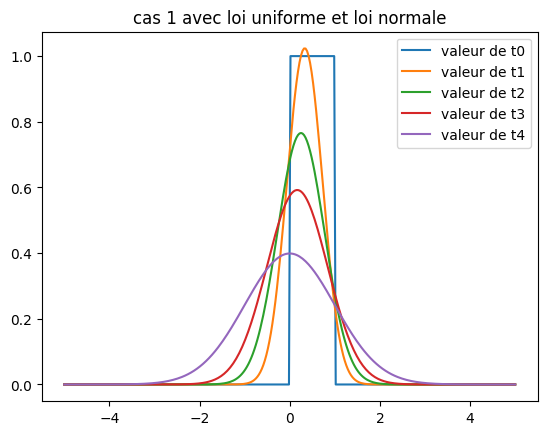

In [3]:
#on pose le x et le t test1 pour représenter la fonction
#
Lx=np.linspace(-5,5,300)
Lt=[0,1/3,1/2,2/3,1]

def fcas1(x0):
    return sps.uniform.pdf(x0, loc=0, scale=1)*sps.norm.pdf((x-(1-t)*x0)/t, loc=0, scale=1)
Ftcas1=[]
plt.plot(Lx, sps.uniform.pdf(Lx, loc=0, scale=1),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas1,0,1)
        Ft.append((1/t)*integrale[0])
    Ftcas1.append(Ft)
    plt.plot(Lx, Ftcas1[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 1 avec loi uniforme et loi normale")

Text(0.5, 1.0, 'cas 2 avec deux lois uniformes')

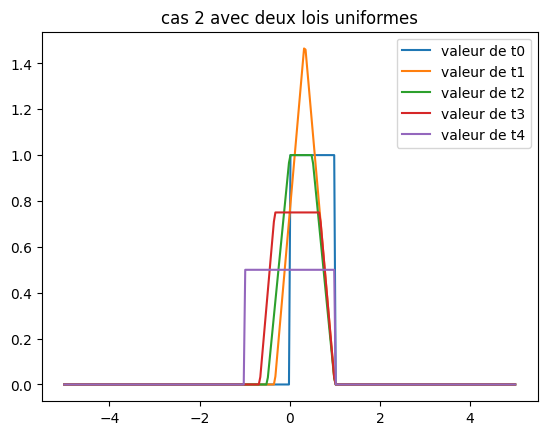

In [3]:

def fcas2(x0):
    return sps.uniform.pdf(x0, loc=0, scale=1)*sps.uniform.pdf((x-(1-t)*x0)/t, loc=-1, scale=2)
Ftcas2=[]
plt.plot(Lx, sps.uniform.pdf(Lx, loc=0, scale=1),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas2,0,1)
        Ft.append((1/t)*integrale[0])
    Ftcas2.append(Ft)
    plt.plot(Lx, Ftcas2[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 2 avec deux lois uniformes")

Text(0.5, 1.0, 'cas 2 avec deux lois normales')

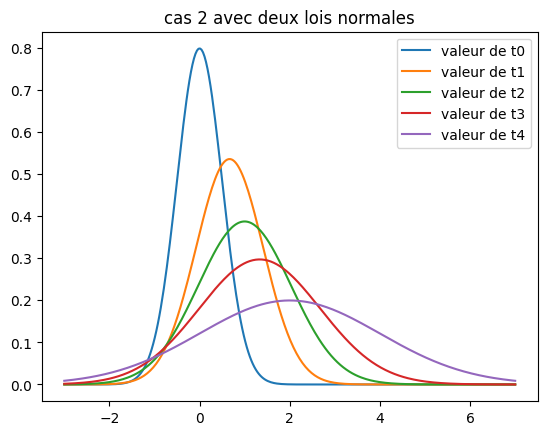

In [4]:
Lx=np.linspace(-3,7,300)
def fcas3(x0):
    return sps.norm.pdf(x0, loc=0, scale=0.5)*sps.norm.pdf((x-(1-t)*x0)/t, loc=2, scale=2)
Ftcas3=[]
plt.plot(Lx, sps.norm.pdf(Lx, loc=0, scale=0.5),label="valeur de t"+str(0))
for i in range(1, len(Lt)):
    t=Lt[i]
    Ft=[]
    for x in Lx:
        integrale=spi.quad(fcas3,-np.inf, np.inf)
        Ft.append((1/t)*integrale[0])
    Ftcas3.append(Ft)
    plt.plot(Lx, Ftcas3[i-1], label="valeur de t"+str(i))
plt.legend()
plt.title("cas 2 avec deux lois normales")

[T2] La classe des mesures de Dirac est close par cette opération. En effet,
si on a $f_y, f_x:M\rightarrow\mathbb R$ les v.a. de mesures image $\delta_x, \delta_y$
on a évidament $\mathbb P(tf_y+(1-t)f_x = ty+(1-t)x)=1$, comme $f_y^{-1}[y]\cap
f_x^{-1}[x]$ est de mesure 1, et donc on a pour mesure image $\delta_{tx+(1-t)y}$.

Les mesure uniform sur un interval ne sont pas clos, comme si $X$, $Y$
suivent $U([0,1])$ et qu'on regarde $Z=(X+Y)/2$, une calcule du fonction de densité
donne
\begin{align*}
    \mathbb E f(Z)&=\int f((x+y)/2)\chi_{[0,1]}(x)\chi_{[0,1]}(y)dxdy\\
    &=\int f(z)\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx 2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx\right)2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx\right)2dz
\end{align*}
donc la fonction de densité $d(z) = 2\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx$,
et comme on sait que $Z\in[0,1]$, on devrait avoir $d(z)=1$ sur $[0,1]$, mais
déjà $d$ n'est pas constante. Et finalement les mesures Gaussiennes sont closes
par cette opération et cela fait partie de théorie de notre cours.


[T3]

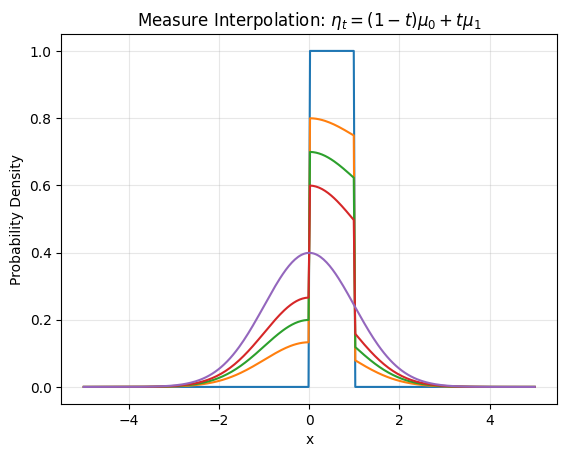

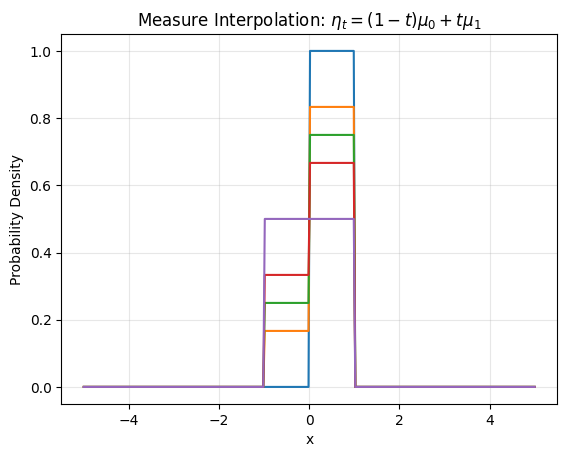

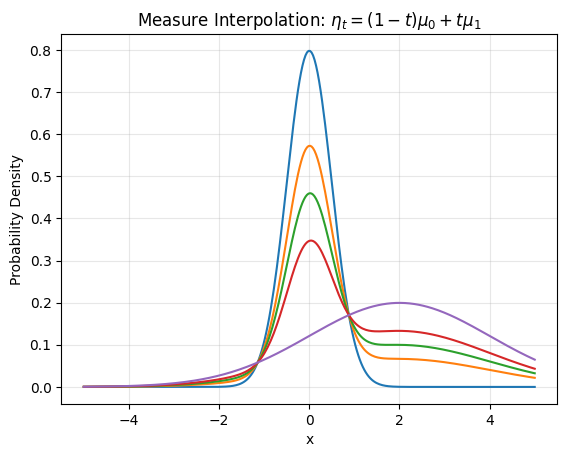

In [6]:
from scipy.stats import norm, uniform

def meas_inter(f, g, name):
    for t in Lt:
        plt.title(r"Measure Interpolation: $\eta_t = (1-t)\mu_0 + t\mu_1$")
        plt.xlabel("x")
        plt.ylabel("Probability Density")
        plt.grid(True, alpha=0.3)
        plt.plot(Lx, (1-t)*f(Lx) + t*g(Lx), label=f"t = {t}")
    plt.show()

meas_inter(uniform.pdf, norm.pdf, "unif+norm")
meas_inter(uniform.pdf, uniform(loc=-1, scale=2).pdf, "unif+unif")
meas_inter(norm(scale=0.5).pdf, norm(loc=2, scale=2).pdf, "norm+norm")